# Final Project - Sleep Disorder Prediction Based on Lifestyle and Health Index
Haocheng Jin

Dataset URL: https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/data

## Problem Definition
The goal of this project is to predict sleep disorder risk using demographic, lifestyle, and health-related features from the dataset. The target variable is sleep_disorder_risk, and the input features include factors such as age, gender, BMI, sleep duration, sleep quality, screen time, exercise, stress score, work hours, and so on. This is a supervised classification problem, since the model will learn from labeled data to predict the sleep disorder category. The dataset contains 100,000 samples with both numerical and categorical features, so preprocessing such as encoding and scaling will be required. This task is meaningful because sleep disorders are closely related to overall health and daily performance, and predicting risk based on common lifestyle factors can help with early awareness and intervention. Models like logistic regression, KNN, Decision Tree, Random Forest, Gradient Boosting, and SVM, will be trained and used to predict the risk of sleep disorder.

## **Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

## **EDA**

In [2]:
# read file
df = pd.read_csv("sleep_health_dataset.csv")

# show head
print(df.head())

   person_id  age  gender         occupation   bmi country  \
0          1   29  Female             Driver  25.7   Japan   
1          2   55  Female  Software Engineer  22.0     USA   
2          3   42    Male              Nurse  25.0   India   
3          4   37  Female            Student  29.5   India   
4          5   23    Male             Lawyer  23.6   Spain   

   sleep_duration_hrs  sleep_quality_score  rem_percentage  \
0                6.19                  6.6            22.5   
1                8.32                  6.9            26.9   
2                3.74                  1.0            20.2   
3                6.79                  6.4            17.7   
4                5.02                  3.2            23.3   

   deep_sleep_percentage  ...  heart_rate_resting_bpm  sleep_aid_used  \
0                   19.3  ...                      63               0   
1                   14.9  ...                      52               1   
2                   16.2  ...      

There are 3 targets, 28 features, and 1 unnecessary id.

In [3]:
# show summary statistics
print(df.describe())

           person_id            age            bmi  sleep_duration_hrs  \
count  100000.000000  100000.000000  100000.000000       100000.000000   
mean    50000.500000      34.706870      26.289673            6.423986   
std     28867.657797      11.036373       4.479578            1.274627   
min         1.000000      18.000000      16.000000            3.000000   
25%     25000.750000      26.000000      23.200000            5.530000   
50%     50000.500000      33.000000      26.300000            6.360000   
75%     75000.250000      42.000000      29.300000            7.270000   
max    100000.000000      69.000000      45.000000           10.500000   

       sleep_quality_score  rem_percentage  deep_sleep_percentage  \
count        100000.000000   100000.000000          100000.000000   
mean              4.871144       20.243968              20.253375   
std               1.506517        3.411354               4.251096   
min               1.000000       10.000000               

In [4]:
# show info and feature types
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   occupation                   100000 non-null  str    
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  str    
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  alcohol_uni

In [5]:
# missing values
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


No missing value in the dataset, so no further action needed.

In [6]:
# check target classes
print(df["sleep_disorder_risk"].value_counts())

sleep_disorder_risk
Healthy     54156
Mild        33479
Moderate     8299
Severe       4066
Name: count, dtype: int64


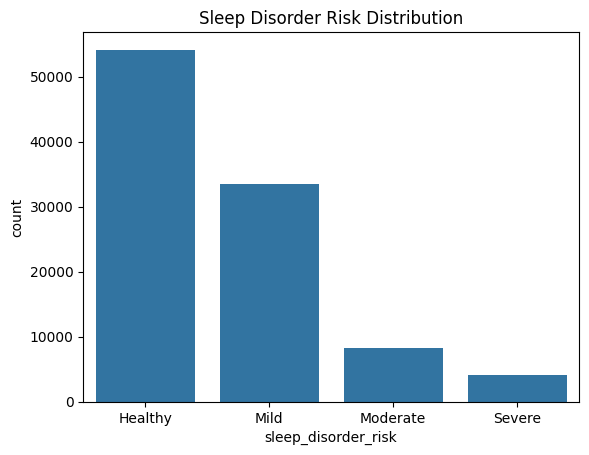

In [7]:
# visualize target distribution
order = ["Healthy", "Mild", "Moderate", "Severe"]

sns.countplot(data=df, x="sleep_disorder_risk", order=order)
plt.title("Sleep Disorder Risk Distribution")
plt.xlabel("sleep_disorder_risk")
plt.ylabel("count")
plt.show()

Target classes are imbalanced, and may cause lower accuracy on the classes with less instances. SMOTE will be implemented later in the model pipelines.

In [8]:
# encode classes
# numeric target for correlation
mapping = {"Healthy": 0, "Mild": 1, "Moderate": 2, "Severe": 3}
df["sleep_disorder_risk_num"] = df["sleep_disorder_risk"].map(mapping)

In [9]:
# check correlation for numerical features
corr = df.corr(numeric_only=True)

sd_corr = corr["sleep_disorder_risk_num"].sort_values(ascending=False)

print(sd_corr)

sleep_disorder_risk_num        1.000000
stress_score                   0.483752
wake_episodes_per_night        0.346527
sleep_latency_mins             0.332583
shift_work                     0.241010
bmi                            0.236847
work_hours_that_day            0.228350
alcohol_units_before_bed       0.108393
caffeine_mg_before_bed         0.096724
age                            0.064827
screen_time_before_bed_mins    0.059930
heart_rate_resting_bpm         0.046748
nap_duration_mins              0.022919
weekend_sleep_diff_hrs         0.001796
room_temperature_celsius      -0.001131
person_id                     -0.003485
steps_that_day                -0.005864
exercise_day                  -0.008934
sleep_aid_used                -0.041090
deep_sleep_percentage         -0.107556
rem_percentage                -0.205061
felt_rested                   -0.387377
sleep_duration_hrs            -0.473561
sleep_quality_score           -0.693763
cognitive_performance_score   -0.703790


From the correlation results above, the top-10 most correlated features are selected to visualize.

In [10]:
# selected important numeric features
top_features = [
    "sleep_quality_score",
    "stress_score",
    "sleep_duration_hrs",
    "wake_episodes_per_night",
    "sleep_latency_mins",
    "bmi",
    "work_hours_that_day",
    "rem_percentage",
    "deep_sleep_percentage",
    "alcohol_units_before_bed"
]

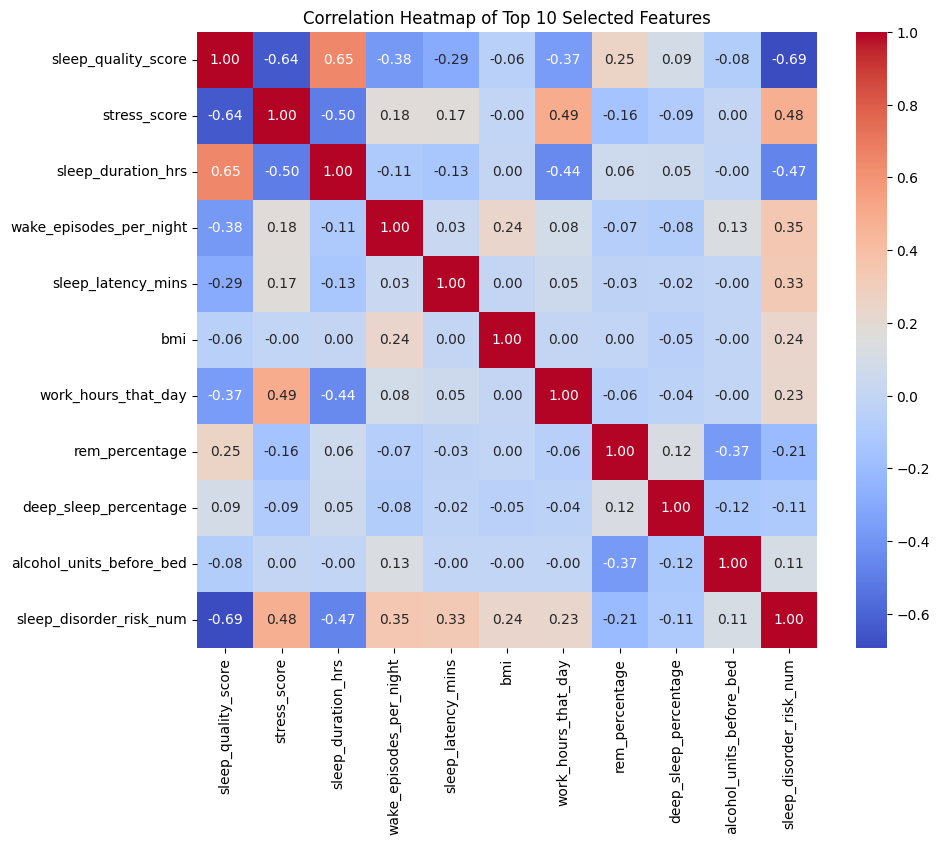

In [11]:
# top feature + target feature
heatmap_features = top_features + ["sleep_disorder_risk_num"]

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(df[heatmap_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Top 10 Selected Features")
plt.show()

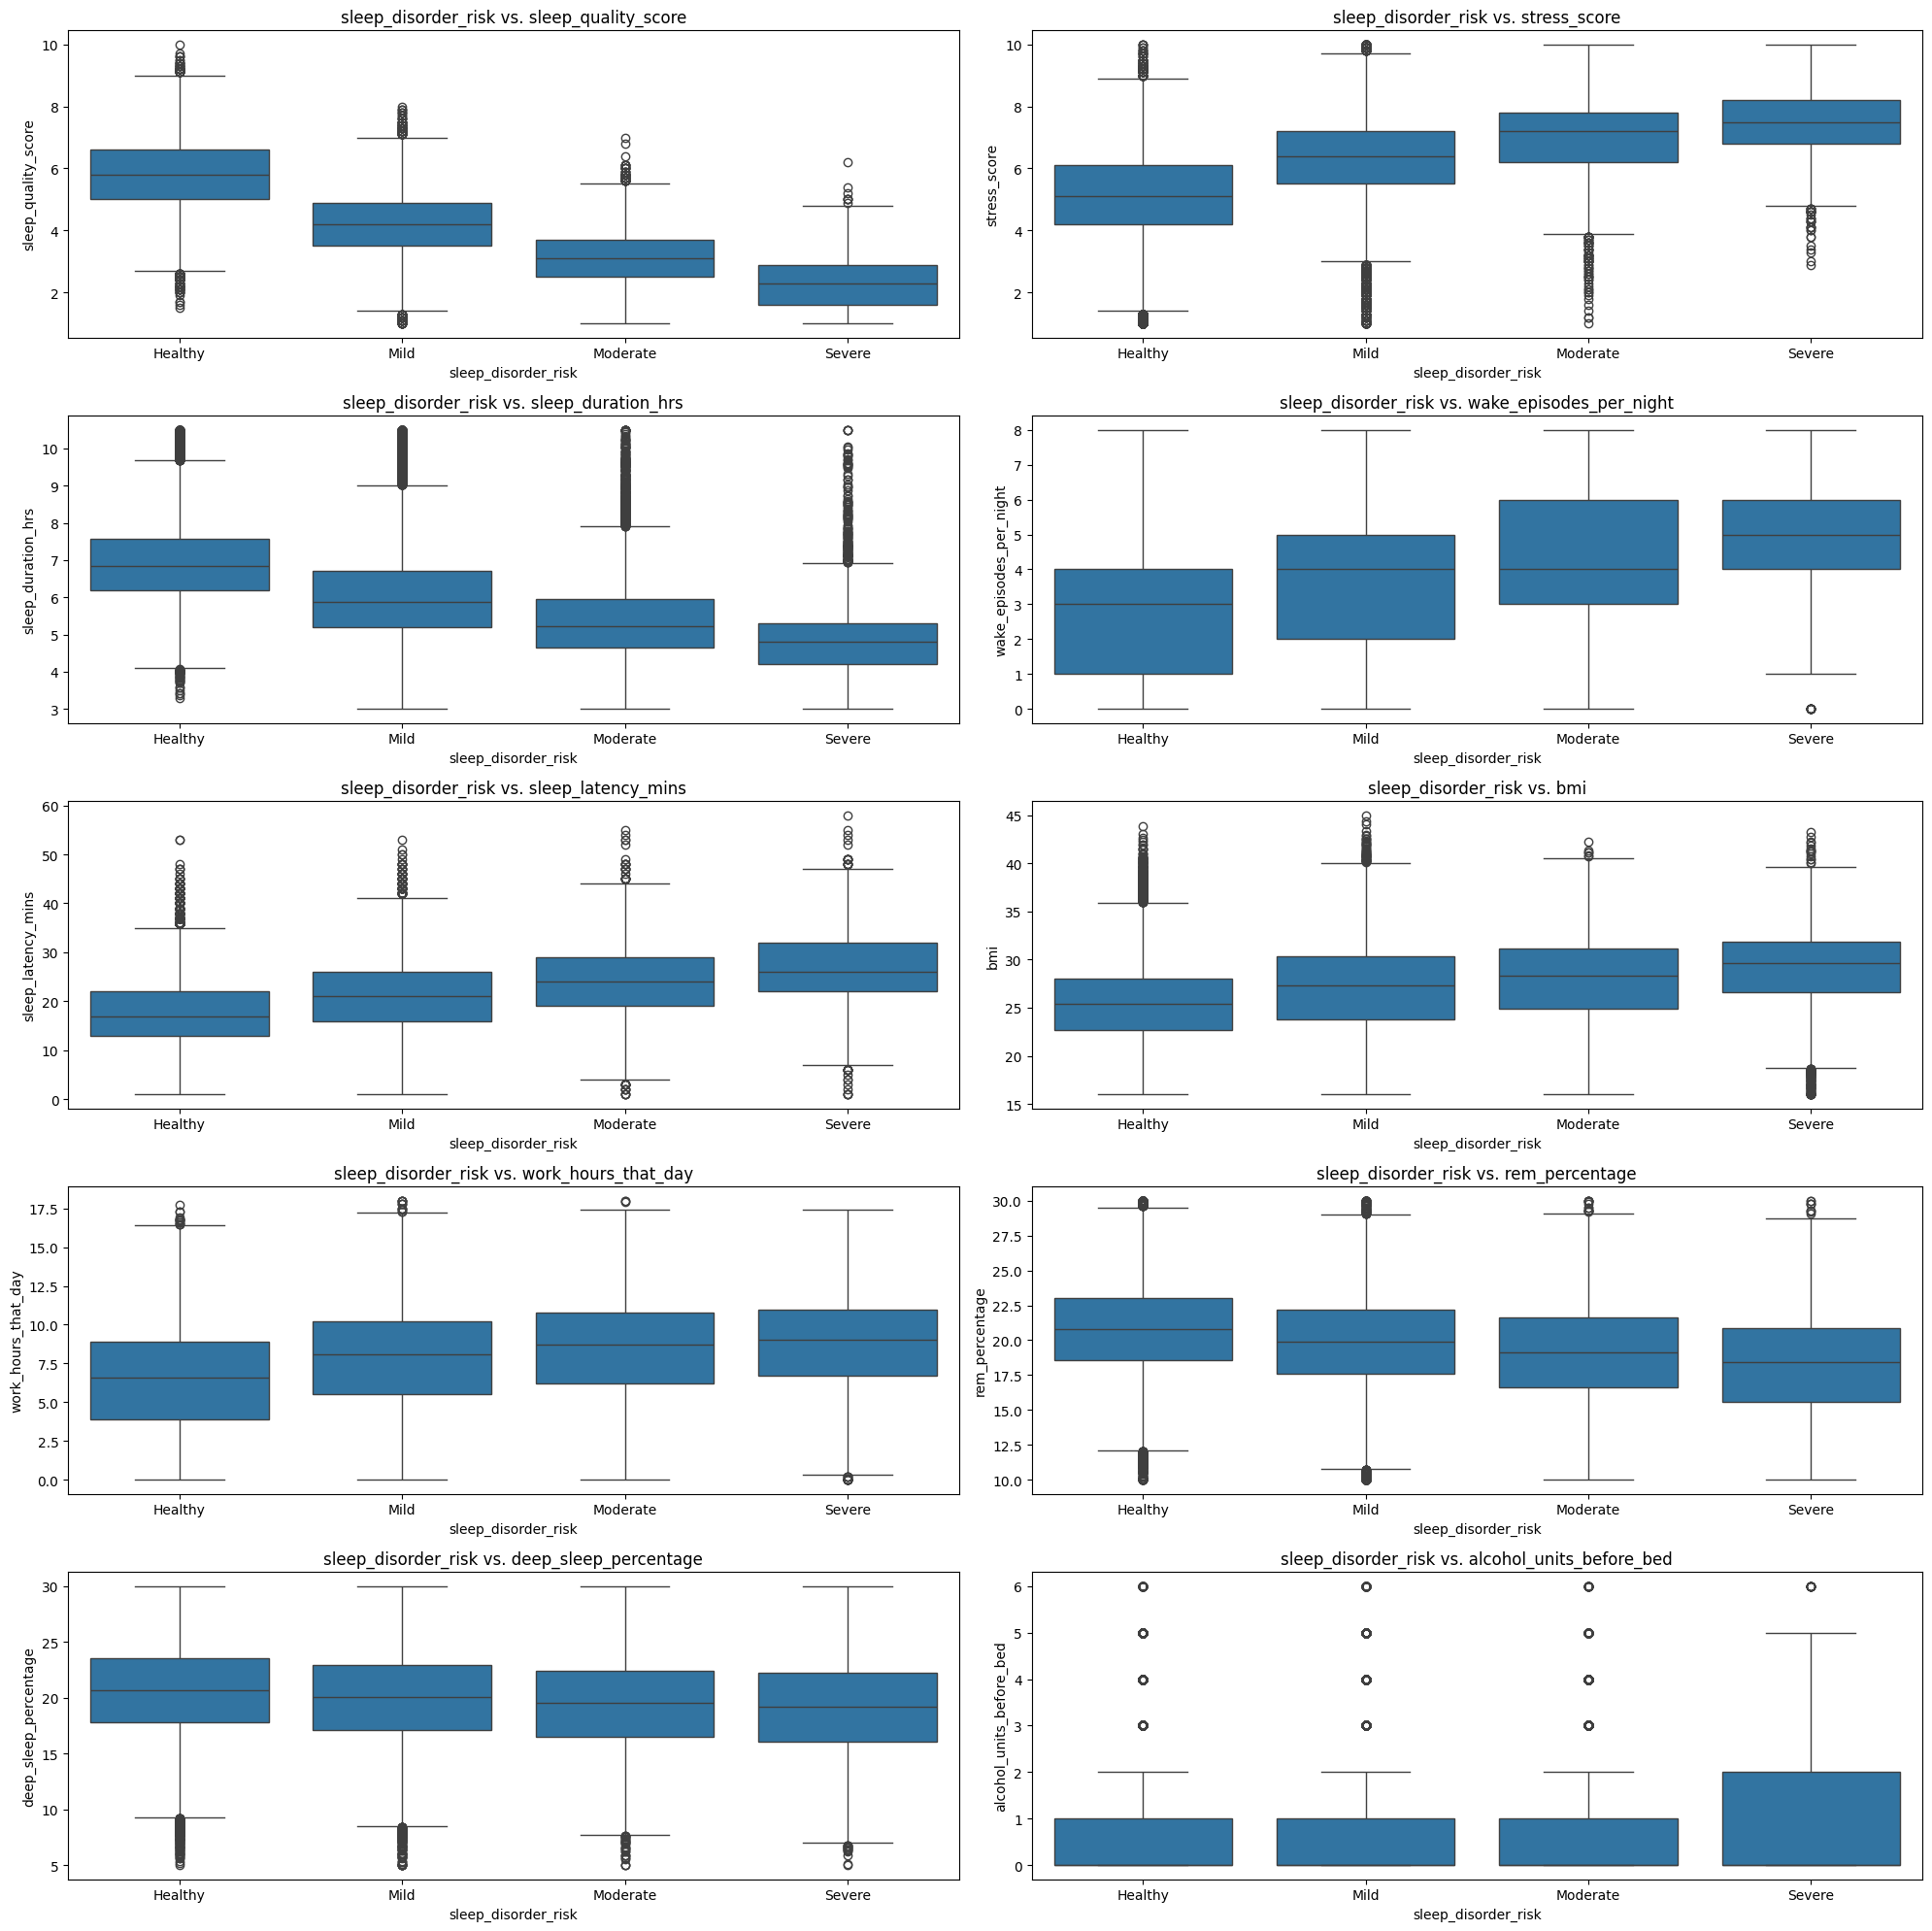

In [12]:
# boxplots
plt.figure(figsize=(20, 20))

for i, col in enumerate(top_features, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(data=df, x="sleep_disorder_risk", y=col, order=order)
    plt.title(f"sleep_disorder_risk vs. {col}")

plt.tight_layout()
plt.show()

## Data Preprocessing

In [13]:
# remove unnecessary features
X = df.drop(columns=[
    "sleep_disorder_risk",
    "sleep_disorder_risk_num",
    "felt_rested",
    "cognitive_performance_score",
    "person_id"
], errors="ignore")

# the only target
target = "sleep_disorder_risk"

y = df[target]

# categorical features
cat_features = [
    "gender",
    "occupation",
    "country",
    "chronotype",
    "mental_health_condition",
    "season",
    "day_type"
]

# numerical features
num_features =[
    "age",
    "bmi",
    "sleep_duration_hrs",
    "sleep_quality_score",
    "rem_percentage",
    "deep_sleep_percentage",
    "sleep_latency_mins",
    "wake_episodes_per_night",
    "caffeine_mg_before_bed",
    "alcohol_units_before_bed",
    "screen_time_before_bed_mins",
    "exercise_day",
    "steps_that_day",
    "nap_duration_mins",
    "shift_work",
    "stress_score",
    "work_hours_that_day",
    "heart_rate_resting_bpm",
    "room_temperature_celsius",
    "weekend_sleep_diff_hrs"
]

# check
print("Categorical features:", cat_features)
print("Numerical features:", num_features)


Categorical features: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type']
Numerical features: ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'shift_work', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'room_temperature_celsius', 'weekend_sleep_diff_hrs']


In [14]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
# transformers
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# preprocessor
preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
])

In [16]:
# fit and transform
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("X_train shape before preprocessing:", X_train.shape)
print("X_test shape before preprocessing:", X_test.shape)
print("X_train shape after preprocessing:", X_train_prepared.shape)
print("X_test shape after preprocessing:", X_test_prepared.shape)

X_train shape before preprocessing: (80000, 28)
X_test shape before preprocessing: (20000, 28)
X_train shape after preprocessing: (80000, 63)
X_test shape after preprocessing: (20000, 63)


## Model Training

### Logistic Regression

In [17]:
# logistic regression pipeline
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        #class_weight="balanced",   # deal with imbalanced dataset
        random_state=42
    ))
])

# implement SMOTE for balancing classes
lr_model_smote = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# train
lr_model.fit(X_train, y_train)
lr_model_smote.fit(X_train, y_train)

# predict both sets
y_pred_lr = lr_model.predict(X_test)
y_pred_lr_smote = lr_model_smote.predict(X_test)

# evaluation
print("Logistic Regression")
print("---Original Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("---SMOTE Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_smote))
print("Classification Report:")
print(classification_report(y_test, y_pred_lr_smote))

Logistic Regression
---Original Set---
Accuracy: 0.82695
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.90      0.91      0.91     10831
        Mild       0.76      0.79      0.78      6696
    Moderate       0.58      0.48      0.53      1660
      Severe       0.78      0.66      0.71       813

    accuracy                           0.83     20000
   macro avg       0.76      0.71      0.73     20000
weighted avg       0.82      0.83      0.82     20000

---SMOTE Set---
Accuracy: 0.8042
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.93      0.88      0.90     10831
        Mild       0.76      0.72      0.74      6696
    Moderate       0.46      0.65      0.54      1660
      Severe       0.66      0.79      0.72       813

    accuracy                           0.80     20000
   macro avg       0.70      0.76      0.72     20000
weighted avg       0.82      0.80      0.81     2

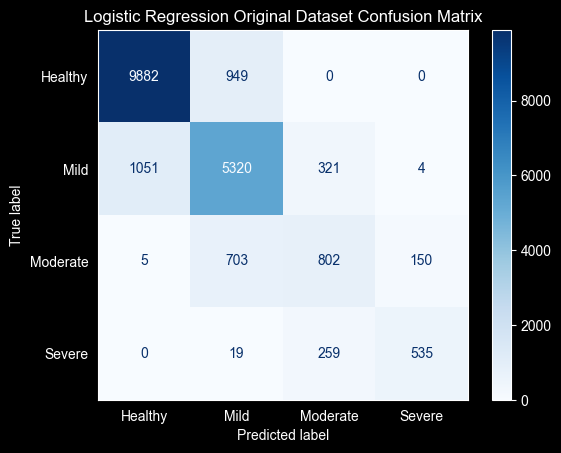

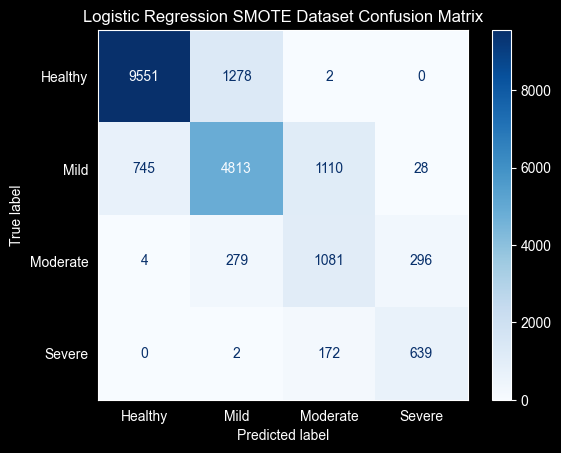

In [19]:
# confusion matrices
cm = confusion_matrix(y_test, y_pred_lr)
cm_smote = confusion_matrix(y_test, y_pred_lr_smote)

# plot
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("Logistic Regression Original Dataset Confusion Matrix")
plt.show()

disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=lr_model_smote.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("Logistic Regression SMOTE Dataset Confusion Matrix")
plt.show()

### KNN

In [53]:
# KNN pipeline
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

# KNN pipeline with SMOTE
knn_model_smote = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

# train
knn_model.fit(X_train, y_train)
knn_model_smote.fit(X_train, y_train)

# predict
y_pred_knn = knn_model.predict(X_test)
y_pred_knn_smote = knn_model_smote.predict(X_test)

# evaluation
print("KNN")
print("---Original Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

print("---SMOTE Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_smote))
print("Classification Report:")
print(classification_report(y_test, y_pred_knn_smote))

KNN
---Original Set---
Accuracy: 0.7156
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.78      0.92      0.84     10831
        Mild       0.62      0.58      0.60      6696
    Moderate       0.39      0.16      0.22      1660
      Severe       0.76      0.23      0.35       813

    accuracy                           0.72     20000
   macro avg       0.64      0.47      0.50     20000
weighted avg       0.69      0.72      0.69     20000

---SMOTE Set---
Accuracy: 0.6787
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.88      0.79      0.84     10831
        Mild       0.59      0.56      0.58      6696
    Moderate       0.28      0.47      0.35      1660
      Severe       0.39      0.56      0.46       813

    accuracy                           0.68     20000
   macro avg       0.54      0.60      0.56     20000
weighted avg       0.72      0.68      0.69     20000



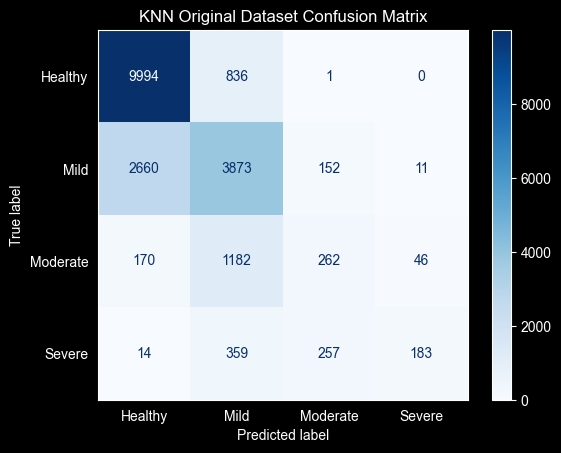

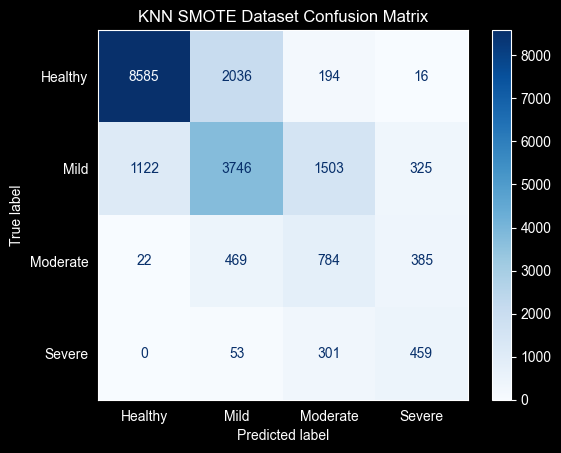

In [54]:
# confusion matrices
cm = confusion_matrix(y_test, y_pred_knn)
cm_smote = confusion_matrix(y_test, y_pred_knn_smote)

# original
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("KNN Original Dataset Confusion Matrix")
plt.show()

# smote
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=knn_model_smote.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("KNN SMOTE Dataset Confusion Matrix")
plt.show()

### Decision Tree

In [55]:
# Decision Tree pipeline
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=10,
        random_state=42
    ))
])

# Decision Tree pipeline with SMOTE
dt_model_smote = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=10,
        random_state=42
    ))
])

# train
dt_model.fit(X_train, y_train)
dt_model_smote.fit(X_train, y_train)

# predict
y_pred_dt = dt_model.predict(X_test)
y_pred_dt_smote = dt_model_smote.predict(X_test)

# evaluation
print("Decision Tree")
print("---Original Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("---SMOTE Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_smote))
print("Classification Report:")
print(classification_report(y_test, y_pred_dt_smote))

Decision Tree
---Original Set---
Accuracy: 0.8828
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.94      0.97      0.95     10831
        Mild       0.86      0.85      0.85      6696
    Moderate       0.62      0.57      0.59      1660
      Severe       0.76      0.69      0.73       813

    accuracy                           0.88     20000
   macro avg       0.80      0.77      0.78     20000
weighted avg       0.88      0.88      0.88     20000

---SMOTE Set---
Accuracy: 0.8559
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.94      0.94      0.94     10831
        Mild       0.84      0.79      0.81      6696
    Moderate       0.52      0.67      0.59      1660
      Severe       0.70      0.69      0.70       813

    accuracy                           0.86     20000
   macro avg       0.75      0.77      0.76     20000
weighted avg       0.86      0.86      0.86     20000



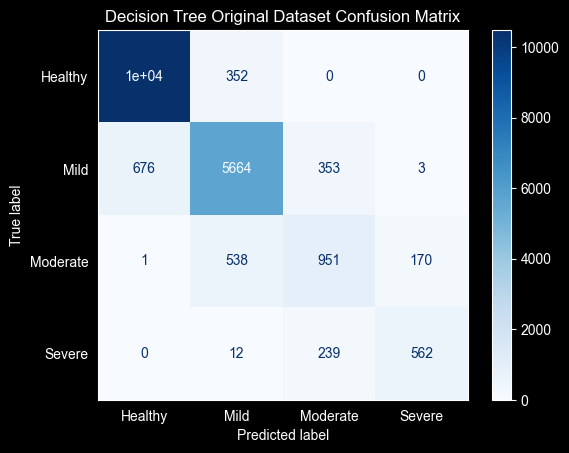

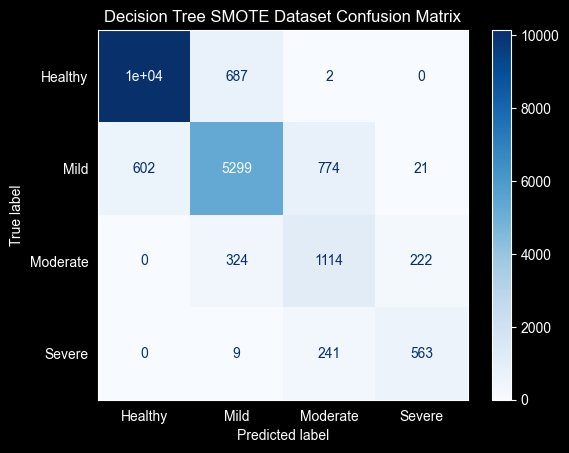

In [56]:
# confusion matrices
cm = confusion_matrix(y_test, y_pred_dt)
cm_smote = confusion_matrix(y_test, y_pred_dt_smote)

# original
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_model.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("Decision Tree Original Dataset Confusion Matrix")
plt.show()

# smote
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=dt_model_smote.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("Decision Tree SMOTE Dataset Confusion Matrix")
plt.show()

### Random Forest Model

In [57]:
# Random Forest pipeline
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ))
])

# Random Forest pipeline with SMOTE
rf_model_smote = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ))
])

# train
rf_model.fit(X_train, y_train)
rf_model_smote.fit(X_train, y_train)

# predict
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_smote = rf_model_smote.predict(X_test)

# evaluation
print("Random Forest")
print("---Original Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("---SMOTE Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_smote))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_smote))

Random Forest
---Original Set---
Accuracy: 0.8882
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.95      0.97      0.96     10831
        Mild       0.82      0.91      0.87      6696
    Moderate       0.69      0.40      0.51      1660
      Severe       0.87      0.65      0.75       813

    accuracy                           0.89     20000
   macro avg       0.83      0.73      0.77     20000
weighted avg       0.88      0.89      0.88     20000

---SMOTE Set---
Accuracy: 0.88535
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.96      0.94      0.95     10831
        Mild       0.85      0.87      0.86      6696
    Moderate       0.62      0.67      0.64      1660
      Severe       0.79      0.70      0.74       813

    accuracy                           0.89     20000
   macro avg       0.81      0.79      0.80     20000
weighted avg       0.89      0.89      0.89     20000



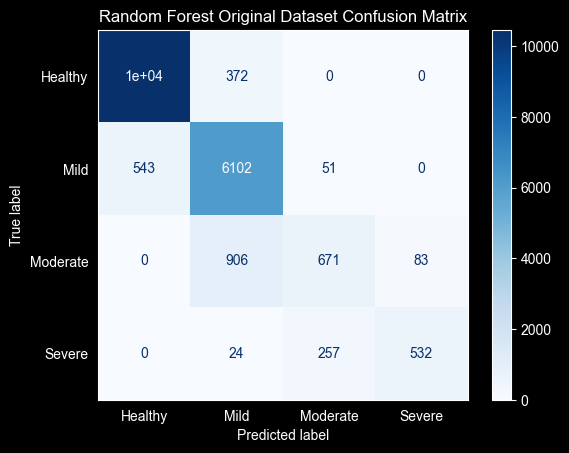

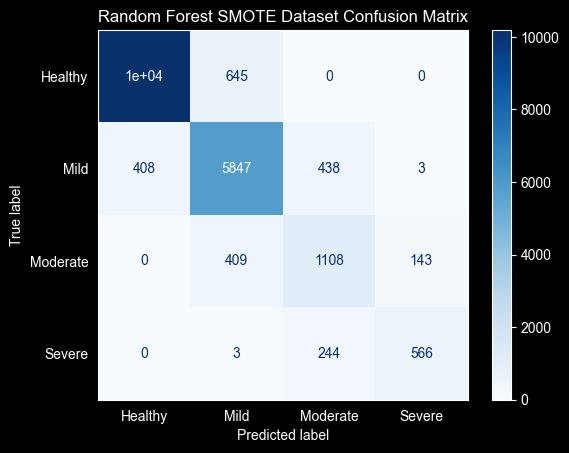

In [58]:
# confusion matrices
cm = confusion_matrix(y_test, y_pred_rf)
cm_smote = confusion_matrix(y_test, y_pred_rf_smote)

# original
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("Random Forest Original Dataset Confusion Matrix")
plt.show()

# smote
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=rf_model_smote.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("Random Forest SMOTE Dataset Confusion Matrix")
plt.show()

Top 10 Feature Importances:
num__sleep_quality_score: 0.173227
num__sleep_duration_hrs: 0.168050
cat__mental_health_condition_Healthy: 0.104666
num__stress_score: 0.084449
num__bmi: 0.081738
num__wake_episodes_per_night: 0.067555
num__sleep_latency_mins: 0.053677
cat__mental_health_condition_Depression: 0.033312
cat__mental_health_condition_Both: 0.027943
cat__mental_health_condition_Anxiety: 0.026888


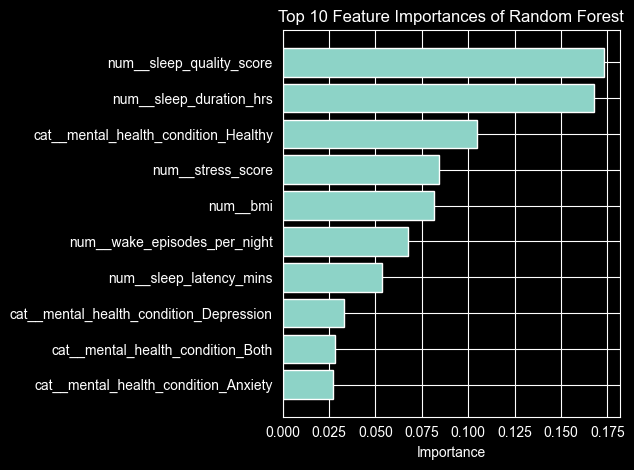

In [59]:
# Random Forest feature importance
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["classifier"].feature_importances_

top_n = 10
top_idx = np.argsort(importances)[-top_n:]

# print values
print("Top 10 Feature Importances:")
for i in top_idx[::-1]:
    print(f"{feature_names[i]}: {importances[i]:.6f}")

# plot
plt.barh(range(top_n), importances[top_idx])
plt.yticks(range(top_n), [feature_names[i] for i in top_idx])
plt.title("Top 10 Feature Importances of Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Gradient Boosting Model

In [60]:
# Gradient Boosting pipeline
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# Gradient Boosting pipeline with SMOTE
gb_model_smote = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# train
gb_model.fit(X_train, y_train)
gb_model_smote.fit(X_train, y_train)

# predict
y_pred_gb = gb_model.predict(X_test)
y_pred_gb_smote = gb_model_smote.predict(X_test)

# evaluation
print("Gradient Boosting")
print("---Original Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Classification Report:")
print(classification_report(y_test, y_pred_gb))

print("---SMOTE Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_gb_smote))
print("Classification Report:")
print(classification_report(y_test, y_pred_gb_smote))

Gradient Boosting
---Original Set---
Accuracy: 0.9403
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      1.00      0.99     10831
        Mild       0.91      0.97      0.94      6696
    Moderate       0.72      0.59      0.65      1660
      Severe       0.87      0.70      0.77       813

    accuracy                           0.94     20000
   macro avg       0.87      0.81      0.84     20000
weighted avg       0.94      0.94      0.94     20000

---SMOTE Set---
Accuracy: 0.91965
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      0.96      0.98     10831
        Mild       0.89      0.92      0.91      6696
    Moderate       0.66      0.69      0.67      1660
      Severe       0.78      0.83      0.80       813

    accuracy                           0.92     20000
   macro avg       0.83      0.85      0.84     20000
weighted avg       0.92      0.92      0.92     200

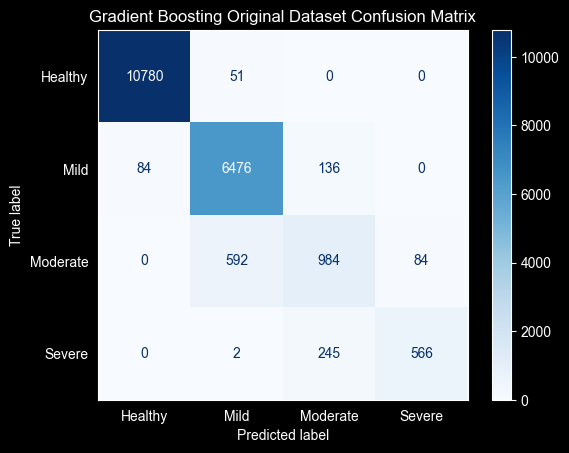

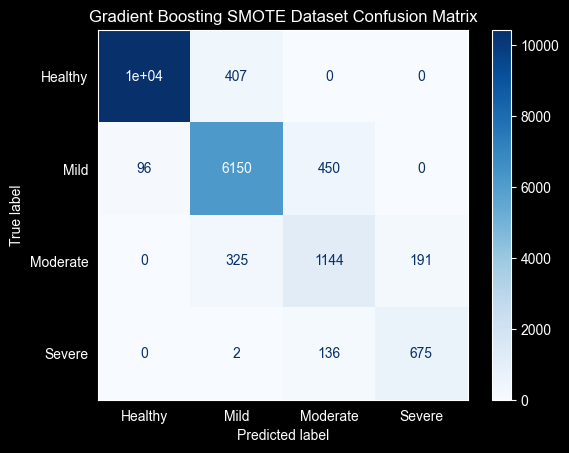

In [61]:
# confusion matrices
cm = confusion_matrix(y_test, y_pred_gb)
cm_smote = confusion_matrix(y_test, y_pred_gb_smote)

# original
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gb_model.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("Gradient Boosting Original Dataset Confusion Matrix")
plt.show()

# smote
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=gb_model_smote.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("Gradient Boosting SMOTE Dataset Confusion Matrix")
plt.show()

Top 10 Feature Importances:
num__sleep_quality_score: 0.402358
cat__mental_health_condition_Healthy: 0.150181
num__sleep_duration_hrs: 0.129156
num__bmi: 0.096477
num__wake_episodes_per_night: 0.057013
num__sleep_latency_mins: 0.053563
num__stress_score: 0.052397
cat__mental_health_condition_Both: 0.018158
num__rem_percentage: 0.008367
num__alcohol_units_before_bed: 0.007378


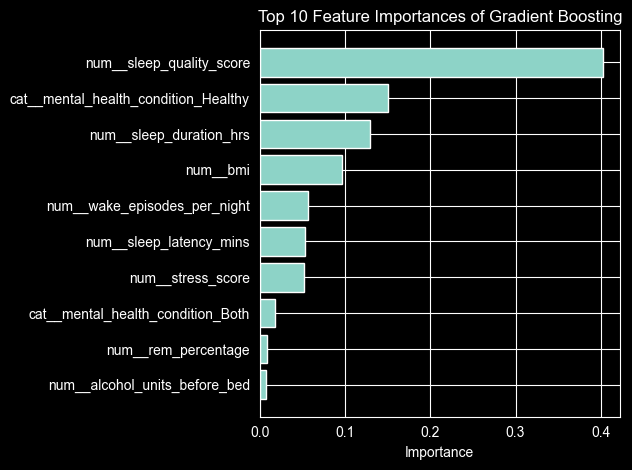

In [62]:
# Gradient Boosting feature importance
feature_names = gb_model.named_steps["preprocessor"].get_feature_names_out()
importances = gb_model.named_steps["classifier"].feature_importances_

top_n = 10
top_idx = np.argsort(importances)[-top_n:]

# print values
print("Top 10 Feature Importances:")
for i in top_idx[::-1]:
    print(f"{feature_names[i]}: {importances[i]:.6f}")

# plot
plt.barh(range(top_n), importances[top_idx])
plt.yticks(range(top_n), [feature_names[i] for i in top_idx])
plt.title("Top 10 Feature Importances of Gradient Boosting")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

The feature importance results show that sleep quality score is the most important factor, which means that it has the strongest influence on predicting sleep disorder risk. Other important features include mental health condition, sleep duration, and BMI, which suggests that both psychological and physical factors play key roles in sleep health. Features such as wake episodes per night, sleep latency, and stress score also contribute to the model, but with smaller impact. Variables like REM percentage and alcohol consumption before bed have very low importance. Overall, the results are consistent with real-world understanding of the causes of sleep disorder.

### SVM

In [63]:
# SVM pipeline
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=42
    ))
])

# SVM pipeline with SMOTE
svm_model_smote = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=42
    ))
])

# train
svm_model.fit(X_train, y_train)
svm_model_smote.fit(X_train, y_train)

# predict
y_pred_svm = svm_model.predict(X_test)
y_pred_svm_smote = svm_model_smote.predict(X_test)

# evaluation
print("SVM")
print("---Original Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))

print("---SMOTE Set---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_smote))
print("Classification Report:")
print(classification_report(y_test, y_pred_svm_smote))

SVM
---Original Set---
Accuracy: 0.85965
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.93      0.94      0.93     10831
        Mild       0.80      0.85      0.82      6696
    Moderate       0.61      0.52      0.56      1660
      Severe       0.82      0.66      0.73       813

    accuracy                           0.86     20000
   macro avg       0.79      0.74      0.76     20000
weighted avg       0.86      0.86      0.86     20000

---SMOTE Set---
Accuracy: 0.85005
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.95      0.92      0.93     10831
        Mild       0.80      0.81      0.81      6696
    Moderate       0.54      0.64      0.59      1660
      Severe       0.74      0.72      0.73       813

    accuracy                           0.85     20000
   macro avg       0.76      0.77      0.76     20000
weighted avg       0.86      0.85      0.85     20000



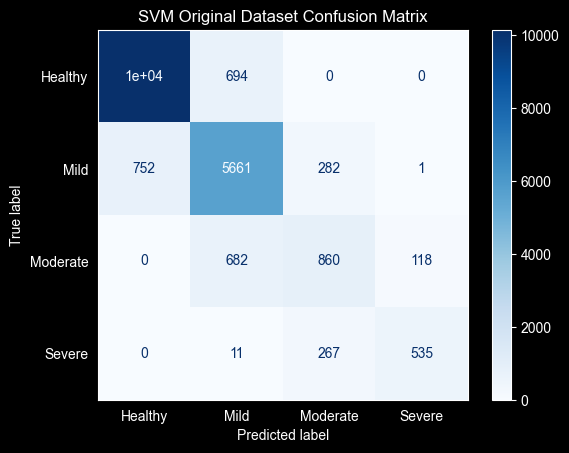

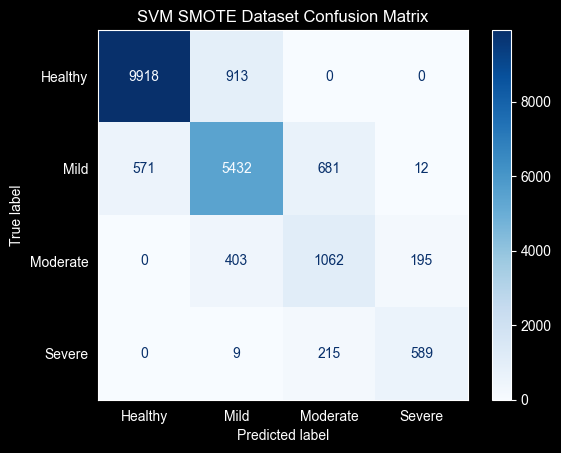

In [64]:
# confusion matrices
cm = confusion_matrix(y_test, y_pred_svm)
cm_smote = confusion_matrix(y_test, y_pred_svm_smote)

# original
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("SVM Original Dataset Confusion Matrix")
plt.show()

# smote
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=svm_model_smote.classes_)
disp_cm.plot(cmap="Blues")
plt.grid(False)
plt.title("SVM SMOTE Dataset Confusion Matrix")
plt.show()

Across all models, the confusion matrices show a consistent pattern related to class imbalance. Most models perform very well on the majority classes, especially Healthy and Mild. However, they often struggle with the minority classes, where Moderate samples are frequently misclassified as Mild and Severe samples as Moderate. After applying SMOTE, the models generally improve their ability to correctly identify Moderate and Severe cases by showing higher recall for these classes.

## Model Evaluation

In [71]:
# store results here
results = []

# function to evaluate each model
def evaluate_model(name, y_true, y_pred):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro"),
        "Recall_macro": recall_score(y_true, y_pred, average="macro"),
        "F1_macro": f1_score(y_true, y_pred, average="macro")
    })

In [72]:
# add each model result
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Logistic Regression with SMOTE", y_test, y_pred_lr_smote)

evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("KNN with SMOTE", y_test, y_pred_knn_smote)

evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Decision Tree with SMOTE", y_test, y_pred_dt_smote)

evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Random Forest with SMOTE", y_test, y_pred_rf_smote)

evaluate_model("Gradient Boosting", y_test, y_pred_gb)
evaluate_model("Gradient Boosting with SMOTE", y_test, y_pred_gb_smote)

evaluate_model("SVM", y_test, y_pred_svm)
evaluate_model("SVM with SMOTE", y_test, y_pred_svm_smote)

# make dataframe
results = pd.DataFrame(results)

# sort by macro F1
results = results.sort_values(by="F1_macro", ascending=False)

print(results)

                             Model  Accuracy  Precision_macro  Recall_macro  \
9     Gradient Boosting with SMOTE   0.91965         0.831242      0.850074   
8                Gradient Boosting   0.94030         0.873335      0.812848   
7         Random Forest with SMOTE   0.88535         0.805582      0.794328   
4                    Decision Tree   0.88280         0.795725      0.769384   
6                    Random Forest   0.88820         0.831307      0.733882   
11                  SVM with SMOTE   0.85005         0.757952      0.772793   
10                             SVM   0.85965         0.790638      0.739371   
5         Decision Tree with SMOTE   0.85590         0.750955      0.772834   
0              Logistic Regression   0.82695         0.755310      0.712019   
1   Logistic Regression with SMOTE   0.80420         0.700813      0.759448   
3                   KNN with SMOTE   0.67870         0.536448      0.597234   
2                              KNN   0.71560        

The results show that Gradient Boosting with SMOTE achieves the best overall performance with better balance across all classes. The original Gradient Boosting model has slightly higher accuracy and precision, but lower recall, showing it favors majority classes more. Random Forest with SMOTE also performs well, suggesting that SMOTE is effective for ensemble tree models. In contrast, Logistic Regression, KNN, and SVM have lower macro F1-scores, and KNN performs the worst overall.

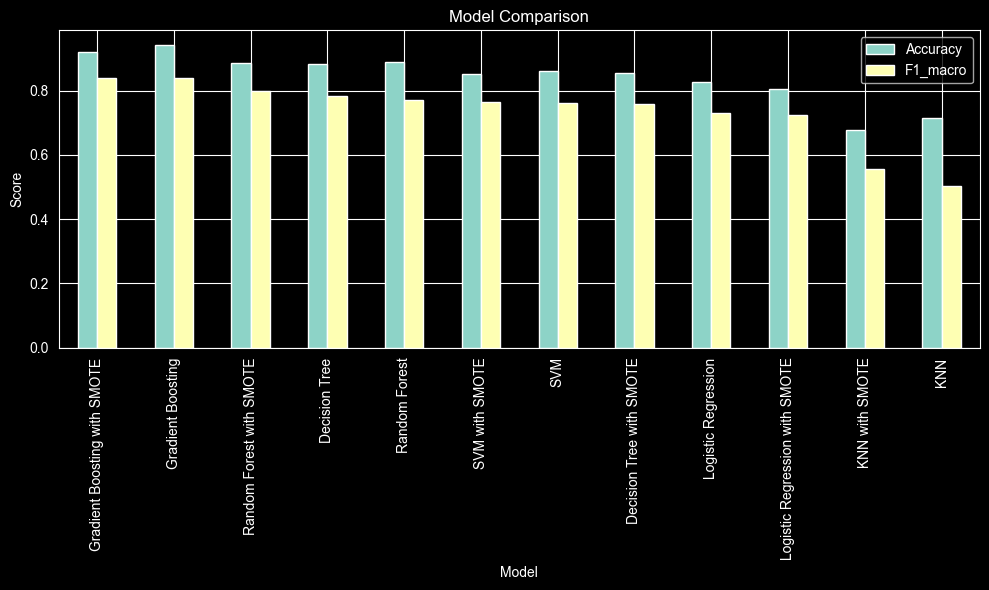

In [73]:
results.plot(x="Model", y=["Accuracy", "F1_macro"], kind="bar", figsize=(10, 6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [74]:
# k-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cross_val(model, X, y, name):
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    print(f"{name} F1_macro CV: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores.mean()

# run for each model
cv_results = []

# Logistic Regression
cv_results.append(("Logistic Regression", cross_val(lr_model, X, y, "LR")))
cv_results.append(("Logistic Regression + SMOTE", cross_val(lr_model_smote, X, y, "LR+SMOTE")))

# KNN
cv_results.append(("KNN", cross_val(knn_model, X, y, "KNN")))
cv_results.append(("KNN + SMOTE", cross_val(knn_model_smote, X, y, "KNN+SMOTE")))

# Decision Tree
cv_results.append(("Decision Tree", cross_val(dt_model, X, y, "DT")))
cv_results.append(("Decision Tree + SMOTE", cross_val(dt_model_smote, X, y, "DT+SMOTE")))

# Random Forest
cv_results.append(("Random Forest", cross_val(rf_model, X, y, "RF")))
cv_results.append(("Random Forest + SMOTE", cross_val(rf_model_smote, X, y, "RF+SMOTE")))

# Gradient Boosting
cv_results.append(("Gradient Boosting", cross_val(gb_model, X, y, "GB")))
cv_results.append(("Gradient Boosting + SMOTE", cross_val(gb_model_smote, X, y, "GB+SMOTE")))

# SVMz
cv_results.append(("SVM", cross_val(svm_model, X, y, "SVM")))
cv_results.append(("SVM + SMOTE", cross_val(svm_model_smote, X, y, "SVM+SMOTE")))

LR F1_macro CV: 0.7358 ± 0.0051
LR+SMOTE F1_macro CV: 0.7255 ± 0.0035
KNN F1_macro CV: 0.5024 ± 0.0017
KNN+SMOTE F1_macro CV: 0.5568 ± 0.0020
DT F1_macro CV: 0.7795 ± 0.0031
DT+SMOTE F1_macro CV: 0.7587 ± 0.0036
RF F1_macro CV: 0.7750 ± 0.0036
RF+SMOTE F1_macro CV: 0.8026 ± 0.0018
GB F1_macro CV: 0.8457 ± 0.0046
GB+SMOTE F1_macro CV: 0.8416 ± 0.0031
SVM F1_macro CV: 0.7653 ± 0.0044
SVM+SMOTE F1_macro CV: 0.7670 ± 0.0035


The 5-fold cross-validation results show that Gradient Boosting achieved the best overall performance, with a macro F1-score of 0.8457 ± 0.0046, then Gradient Boosting with SMOTE at 0.8416 ± 0.0031. This indicates that Gradient Boosting is the most stable and strongest model across different folds. Random Forest with SMOTE also performed well, with a macro F1-score of 0.8026 ± 0.0018. In contrast, KNN had the weakest performance even after SMOTE, which suggests that it is not suitable for this dataset. For Logistic Regression, Decision Tree, and SVM, applying SMOTE did not improve cross-validation performance and slightly reduced macro F1-score. These results suggest that tree-based models are the most effective choice for this task.

## Hyperparameter Tuning
As the results above, gradient boosting + SMOTE model has the best performance. Therefore, hyperparameter tuning will be implemented on it to see the change of performance.

In [75]:
# cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# parameter grid for Gradient Boosting with SMOTE
param_grid_gb_smote = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1, 0.2],
    "classifier__max_depth": [2, 3, 4]
}

# grid search on GB with SMOTE pipeline
grid_gb_smote = GridSearchCV(
    estimator=gb_model_smote,
    param_grid=param_grid_gb_smote,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# fit
grid_gb_smote.fit(X_train, y_train)

# best parameters
print("Best Parameters:", grid_gb_smote.best_params_)
print("Best CV Score:", grid_gb_smote.best_score_)

# best model
best_gb_smote_model = grid_gb_smote.best_estimator_

# test prediction
y_pred_best_gb_smote = best_gb_smote_model.predict(X_test)

# evaluation
print("Tuned Gradient Boosting with SMOTE Accuracy:", accuracy_score(y_test, y_pred_best_gb_smote))
print("Classification Report:")
print(classification_report(y_test, y_pred_best_gb_smote))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_gb_smote))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 4, 'classifier__n_estimators': 200}
Best CV Score: 0.8665831349302726
Tuned Gradient Boosting with SMOTE Accuracy: 0.9505

Classification Report:

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00     10831
        Mild       0.95      0.95      0.95      6696
    Moderate       0.71      0.73      0.72      1660
      Severe       0.83      0.82      0.82       813

    accuracy                           0.95     20000
   macro avg       0.87      0.87      0.87     20000
weighted avg       0.95      0.95      0.95     20000


Confusion Matrix:

[[10793    38     0     0]
 [   15  6334   346     1]
 [    0   308  1217   135]
 [    0     0   147   666]]


In [76]:
# compare
print("GB (no SMOTE) Accuracy:", accuracy_score(y_test, y_pred_gb))
print("GB (no SMOTE) F1_macro:", f1_score(y_test, y_pred_gb, average="macro"))

print("GB + SMOTE Accuracy:", accuracy_score(y_test, y_pred_gb_smote))
print("GB + SMOTE F1_macro:", f1_score(y_test, y_pred_gb_smote, average="macro"))

print("Tuned GB + SMOTE Accuracy:", accuracy_score(y_test, y_pred_best_gb_smote))
print("Tuned GB + SMOTE F1_macro:", f1_score(y_test, y_pred_best_gb_smote, average="macro"))

GB (no SMOTE) Accuracy: 0.9403
GB (no SMOTE) F1_macro: 0.8388761012942012
GB + SMOTE Accuracy: 0.91965
GB + SMOTE F1_macro: 0.8402903521851781
Tuned GB + SMOTE Accuracy: 0.9505
Tuned GB + SMOTE F1_macro: 0.8729107728340679


After hyperparameter tuning, I find that when classifier__learning_rate = 0.2, classifier__max_depth = 4, classifier__n_estimators = 200, the model has the highest accuracy and macro F1.

## Analysis and interpretation
The results show that among all untuned models, Gradient Boosting gave the best overall performance. This suggests that the relationships in this dataset are nonlinear and better captured by ensemble tree methods. After applying SMOTE, recall for minority classes improved in several models, although this may reduce overall accuracy and precision. This is a common tradeoff in imbalanced classification. Better detection of minority classes often comes with more false positives.

The feature importance results from the Gradient Boosting model also provide useful interpretation. Sleep quality score was the most important feature, then features such as mental health condition, sleep duration, BMI, and wake episodes per night. This is reasonable because these factors are strongly related to sleep problems in real life. It also suggests that both physical and mental health factors are important for predicting sleep disorder risk.

The final model was combining the best performing Gradient Boosting model with imbalance handling and hyperparameter tuning. The tuned Gradient Boosting with SMOTE model gave the best balance between overall performance and minority-class prediction. With more time, the work could be improved by testing stronger boosting models such as XGBoost or LightGBM, trying other imbalance methods, and performing more detailed feature selection.

## Comparison to existing work
This problem has been explored in Kaggle notebooks and recent studies. For example, “Sleep Health & Cognitive Performance Analysis” by Mohan Krishna Thalla focuses on exploratory analysis and basic machine learning models on the same dataset. Another Kaggle notebook, “Sleep Disorders Predicted — 95%+ Accuracy” by Harit Mengar, shows that high accuracy can be achieved using structured sleep and lifestyle data. In academic work, “Sleep Disorder Prediction Using Random Forest Classification: A Study on Health and Lifestyle Metrics” by Ateeq, Rehaan, and Ahmed, reports that Random Forest performs best.

Compared to these works, this project focuses more on systematic model comparison and handling class imbalance. six models are tested and evaluate them using macro F1-score, confusion matrices, and cross-validation, rather than relying mainly on accuracy. The results are similar in that tree-based models perform best, but the final model is tuned Gradient Boosting with SMOTE, instead of Random Forest. This difference may be due to the use of imbalance handling and the focus on balanced performance across all classes.

## Real-world or social impact

This project has potential real-world impact in health monitoring and early risk detection. People with sleep problems could benefit from using this model as a simple tool to check themselves. It could also help doctors to quickly identifying risky individuals. However, there are important ethical concerns. Although the dataset is based on liable studies, the dataset is synthetic and may not fully represent real populations. In addition, features such as lifestyle or occupation may introduce fairness issues across different groups. Therefore, this model should be used only as a supportive tool and not as a replacement for professional medical diagnosis.